In [1]:
import scanpy as sc
import numpy as np

adata_align = sc.read_h5ad("data/pathC_alignment.h5ad")
adata_ref   = sc.read_h5ad("data/GSE280305_with_Ref.h5ad")

# sanity check
print(adata_align.n_obs, adata_ref.n_obs)
print(adata_align.obs_names.equals(adata_ref.obs_names))

adata_final = adata_align  # ← key fix

ref_cols = [
    "cluster_label_mannual",
    "scgeo_pred",
    "scgeo_conf_entropy",
    "scgeo_conf_margin",
    "scgeo_conf",
    "scgeo_ood",
    "scgeo_reject",
    "hematlas_pred",
    "hematlas_conf_entropy",
    "hematlas_conf_margin",
    "hematlas_conf",
    "hematlas_ood",
    "hematlas_flag",
]

for col in ref_cols:
    if col in adata_ref.obs.columns:
        adata_final.obs[col] = adata_ref.obs[col].values

# clean naming
adata_final.obs["cluster_label_manual"] = adata_final.obs["cluster_label_mannual"].astype(str)

# derived
adata_final.obs["reference_status"] = np.where(
    adata_final.obs["hematlas_flag"].fillna(False),
    "OOD/high-risk",
    "reference-like"
)

adata_final.obs["state_alignment"] = (
    adata_final.obs["cluster_label_manual"] + " | " +
    adata_final.obs["alignment_group"].astype(str)
)

adata_final.obs["state_reference"] = (
    adata_final.obs["cluster_label_manual"] + " | " +
    adata_final.obs["reference_status"]
)

# save
adata_final.write_h5ad("data/scgeo_gse280305_final_integrated.h5ad")

print(adata_final)

31605 31605
True
AnnData object with n_obs × n_vars = 31605 × 1500
    obs: 'timepoint', 'sample', 'gsm', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'leiden_raw', 'alignment_group', 'cluster_label_mannual', 'scgeo_pred', 'scgeo_conf_entropy', 'scgeo_conf_margin', 'scgeo_conf', 'scgeo_ood', 'scgeo_reject', 'hematlas_pred', 'hematlas_conf_entropy', 'hematlas_conf_margin', 'hematlas_conf', 'hematlas_ood', 'hematlas_flag', 'cluster_label_manual', 'reference_status', 'state_alignment', 'state_reference'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'alignment_group_colors', 'coarse_fwd', 'eigendecomposition_fwd', 'leiden_raw_colors', 'lineages_gpcca_names', 'macrostates_fwd_colors', 'neighb

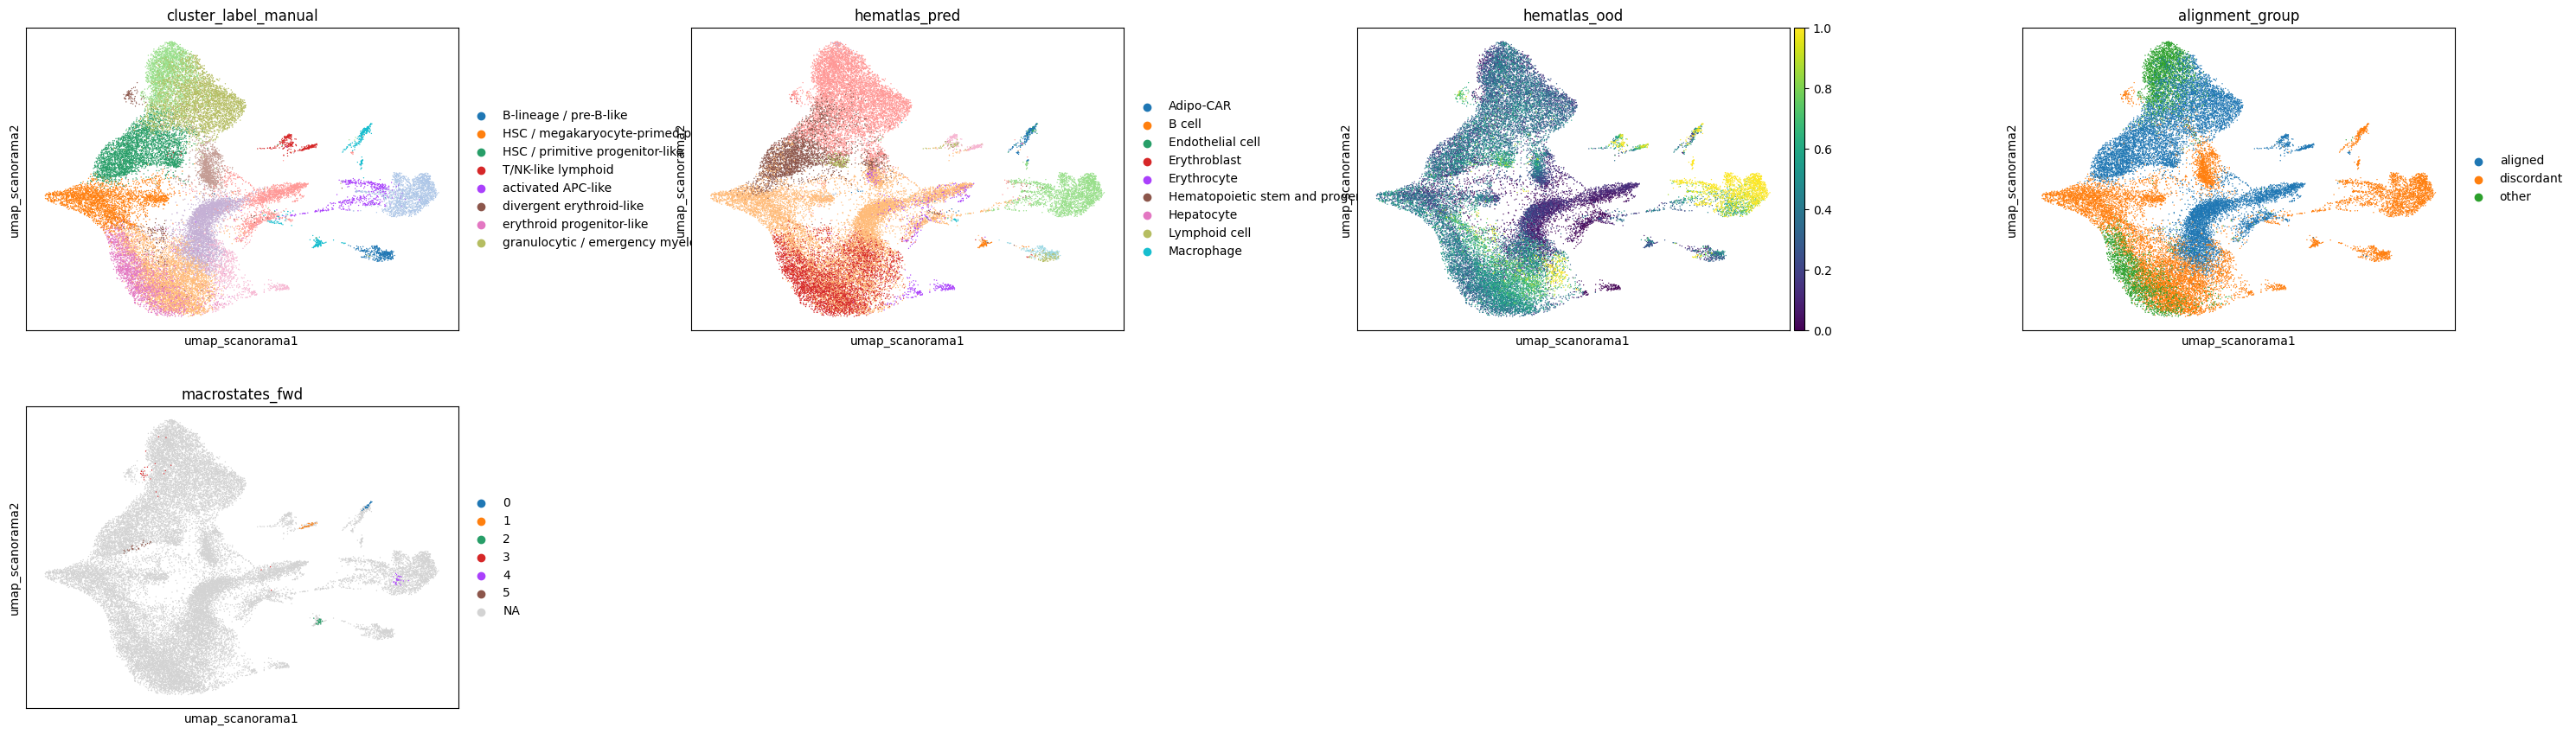

In [2]:
sc.pl.embedding(
    adata_final,
    basis="umap_scanorama",
    color=[
        "cluster_label_manual",
        "hematlas_pred",
        "hematlas_ood",
        "alignment_group",
        "macrostates_fwd",
    ],
    wspace=0.4,
)

In [3]:
for c in [
    "cluster_label_manual",
    "hematlas_pred",
    "alignment_group",
    "reference_status",
    "macrostates_fwd",
    "term_states_fwd",
]:
    print("\n", c)
    print(adata_final.obs[c].astype(str).value_counts().head(20))


 cluster_label_manual
cluster_label_manual
stable erythroid                              5212
stressed erythroid-like                       3921
HSC / primitive progenitor-like               3713
granulocytic / emergency myeloid              3498
HSC / megakaryocyte-primed progenitor-like    3105
stable erythroid-like                         2876
erythroid progenitor-like                     1949
stable APC-like                               1802
stress-associated / ambiguous                 1675
stressed myeloid-like                         1218
transitional erythroid                         729
activated APC-like                             507
macrophage-like / remodeling myeloid           418
B-lineage / pre-B-like                         371
T/NK-like lymphoid                             324
divergent erythroid-like                       287
Name: count, dtype: int64

 hematlas_pred
hematlas_pred
Megakaryocyte                             11827
Myeloid cell                        

In [4]:
df = adata_final.obs.copy()

summary = (
    df.groupby("cluster_label_manual")
    .agg(
        n_cells=("cluster_label_manual", "size"),
        top_ref=("hematlas_pred", lambda x: x.value_counts().idxmax()),
        top_ref_frac=("hematlas_pred", lambda x: x.value_counts(normalize=True).iloc[0]),
        mean_conf=("hematlas_conf", "mean"),
        mean_ood=("hematlas_ood", "mean"),
        flag_frac=("hematlas_flag", "mean"),
        aligned_frac=("alignment_group", lambda x: (x == "aligned").mean()),
        discordant_frac=("alignment_group", lambda x: (x == "discordant").mean()),
    )
    .sort_values(["discordant_frac", "mean_ood"], ascending=[False, False])
)

summary

/tmp/ipykernel_2093/4287753304.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("cluster_label_manual")


,n_cells,top_ref,top_ref_frac,mean_conf,mean_ood,flag_frac,aligned_frac,discordant_frac
cluster_label_manual,,,,,,,,
stable APC-like,1802,Monocyte,1.000000,0.785513,0.891109,0.583796,0.0,1.0
activated APC-like,507,Monocyte,0.773176,0.688708,0.756150,0.607495,0.0,1.0
divergent erythroid-like,287,Erythroblast,0.449477,0.656654,0.683466,0.348432,0.0,1.0
transitional erythroid,729,Megakaryocyte,0.395062,0.853506,0.496187,0.224966,0.0,1.0
macrophage-like / remodeling myeloid,418,Adipo-CAR,0.418660,0.825051,0.473365,0.356459,0.0,1.0
stable erythroid,5212,Megakaryocyte,0.587299,0.920692,0.469226,0.035879,0.0,1.0
B-lineage / pre-B-like,371,pre-B cell,0.663073,0.794313,0.323134,0.159030,0.0,1.0
HSC / megakaryocyte-primed progenitor-like,3105,Megakaryocyte,0.924960,0.823071,0.309894,0.109179,0.0,1.0
stressed myeloid-like,1218,Megakaryocyte,0.448276,0.536984,0.261552,0.605090,0.0,1.0


In [5]:
summary["state_type"] = np.select(
    [
        (summary["aligned_frac"] > 0.6) & (summary["mean_ood"] < summary["mean_ood"].median()),
        (summary["discordant_frac"] > 0.6) & (summary["mean_ood"] > summary["mean_ood"].median()),
    ],
    [
        "canonical / trajectory-consistent",
        "perturbed / trajectory-discordant",
    ],
    default="intermediate / mixed"
)

summary

,n_cells,top_ref,top_ref_frac,mean_conf,mean_ood,flag_frac,aligned_frac,discordant_frac,state_type
cluster_label_manual,,,,,,,,,
stable APC-like,1802,Monocyte,1.000000,0.785513,0.891109,0.583796,0.0,1.0,perturbed / trajectory-discordant
activated APC-like,507,Monocyte,0.773176,0.688708,0.756150,0.607495,0.0,1.0,perturbed / trajectory-discordant
divergent erythroid-like,287,Erythroblast,0.449477,0.656654,0.683466,0.348432,0.0,1.0,perturbed / trajectory-discordant
transitional erythroid,729,Megakaryocyte,0.395062,0.853506,0.496187,0.224966,0.0,1.0,perturbed / trajectory-discordant
macrophage-like / remodeling myeloid,418,Adipo-CAR,0.418660,0.825051,0.473365,0.356459,0.0,1.0,perturbed / trajectory-discordant
stable erythroid,5212,Megakaryocyte,0.587299,0.920692,0.469226,0.035879,0.0,1.0,perturbed / trajectory-discordant
B-lineage / pre-B-like,371,pre-B cell,0.663073,0.794313,0.323134,0.159030,0.0,1.0,intermediate / mixed
HSC / megakaryocyte-primed progenitor-like,3105,Megakaryocyte,0.924960,0.823071,0.309894,0.109179,0.0,1.0,intermediate / mixed
stressed myeloid-like,1218,Megakaryocyte,0.448276,0.536984,0.261552,0.605090,0.0,1.0,intermediate / mixed


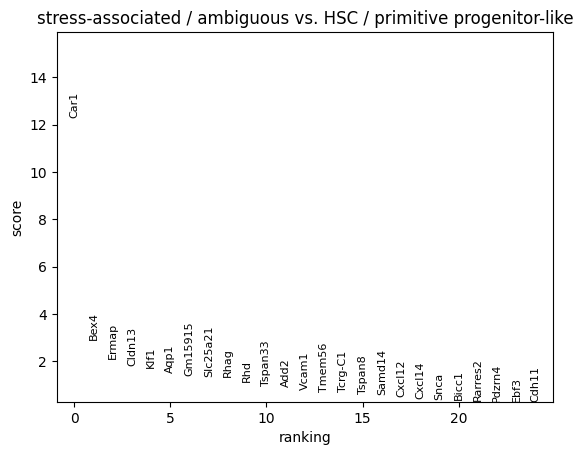

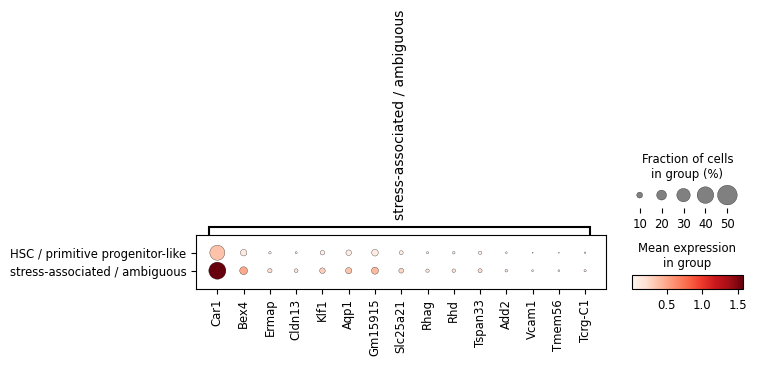

In [6]:
adata = adata_final

# choose one contrast
target = "stress-associated / ambiguous"
ref = "HSC / primitive progenitor-like"

sub = adata[adata.obs["cluster_label_manual"].isin([target, ref])].copy()
sub.obs["contrast"] = sub.obs["cluster_label_manual"].astype(str)

sc.tl.rank_genes_groups(
    sub,
    groupby="contrast",
    groups=[target],
    reference=ref,
    method="wilcoxon",
    pts=True,
)

sc.pl.rank_genes_groups(sub, n_genes=25, sharey=False)
sc.pl.rank_genes_groups_dotplot(sub, n_genes=15)

In [7]:
deg = sc.get.rank_genes_groups_df(sub, group=target)
deg.head(30)

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
0,Car1,12.310708,3.101207,7.932381e-35,1.833370e-34,0.414925
1,Bex4,2.909075,2.345445,3.624997e-03,5.320446e-03,0.146866
2,Ermap,2.122318,3.097552,3.381104e-02,4.652896e-02,0.066269
3,Cldn13,1.816104,3.068308,6.935449e-02,9.338576e-02,0.054328
4,Klf1,1.721058,2.427735,8.524022e-02,1.138560e-01,0.093731
5,Aqp1,1.530448,2.338233,1.259059e-01,1.649422e-01,0.108657
6,Gm15915,1.400946,2.218126,1.612303e-01,2.077710e-01,0.126567
7,Slc25a21,1.356564,2.434219,1.749197e-01,2.248325e-01,0.076418
8,Rhag,1.349393,2.737036,1.772108e-01,2.273877e-01,0.048358
9,Rhd,1.145849,2.458422,2.518576e-01,3.172010e-01,0.050746


In [8]:
deg_sig = deg.query("pvals_adj < 0.05 and logfoldchanges > 0.25").copy()
deg_sig.head(50)

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
0,Car1,12.310708,3.101207,7.932381e-35,1.833370e-34,0.414925
1,Bex4,2.909075,2.345445,3.624997e-03,5.320446e-03,0.146866
2,Ermap,2.122318,3.097552,3.381104e-02,4.652896e-02,0.066269
414,Hpn,-2.128600,0.854216,3.328736e-02,4.589250e-02,0.031642
424,Crip2,-2.230325,1.128345,2.572590e-02,3.579670e-02,0.048358
427,Ccl6,-2.248092,0.541013,2.457030e-02,3.428413e-02,0.016119
442,Iigp1,-2.445846,0.504330,1.445127e-02,2.044991e-02,0.040597
457,Cyth3,-2.641178,0.838437,8.261837e-03,1.185910e-02,0.042388
464,Hbb-bs,-2.767596,1.645384,5.647150e-03,8.160622e-03,0.141493
484,Lgals3,-2.991424,0.903491,2.776800e-03,4.095575e-03,0.038806


In [10]:
import gseapy as gp

genes = deg_sig["names"].dropna().tolist()

enr = gp.enrichr(
    gene_list=genes,
    gene_sets=[
        "MSigDB_Hallmark_2020",
        "GO_Biological_Process_2023",
        "Reactome_2022",
    ],
    organism="mouse",
    outdir=None,
)

enr.results.head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,heme Metabolism,3/200,0.001319,0.017141,0,0,15.854395,105.134068,CPOX;BLVRB;ERMAP
1,MSigDB_Hallmark_2020,Coagulation,2/138,0.009975,0.052401,0,0,14.589706,67.225024,HPN;CRIP2
2,MSigDB_Hallmark_2020,Estrogen Response Late,2/200,0.020154,0.052401,0,0,9.989899,39.003901,BLVRB;S100A9
3,MSigDB_Hallmark_2020,Allograft Rejection,2/200,0.020154,0.052401,0,0,9.989899,39.003901,CD74;ELANE
4,MSigDB_Hallmark_2020,Complement,2/200,0.020154,0.052401,0,0,9.989899,39.003901,LGALS3;S100A9
5,MSigDB_Hallmark_2020,Cholesterol Homeostasis,1/74,0.078354,0.169766,0,0,12.984344,33.064947,LGALS3
6,MSigDB_Hallmark_2020,Interferon Alpha Response,1/97,0.101488,0.188478,0,0,9.862103,22.562635,CD74
7,MSigDB_Hallmark_2020,Fatty Acid Metabolism,1/158,0.160192,0.198463,0,0,6.011829,11.009965,CPOX
8,MSigDB_Hallmark_2020,Apoptosis,1/161,0.162982,0.198463,0,0,5.898214,10.700033,LGALS3
9,MSigDB_Hallmark_2020,Xenobiotic Metabolism,1/200,0.198463,0.198463,0,0,4.732950,7.653913,BLVRB


In [11]:
sc.tl.rank_genes_groups(
    adata_final,
    groupby="alignment_group",
    groups=["discordant"],
    reference="aligned",
    method="wilcoxon"
)

In [12]:
discordant_genes = sc.get.rank_genes_groups_df(adata_final, group="discordant")

In [14]:
import scgeo as sg

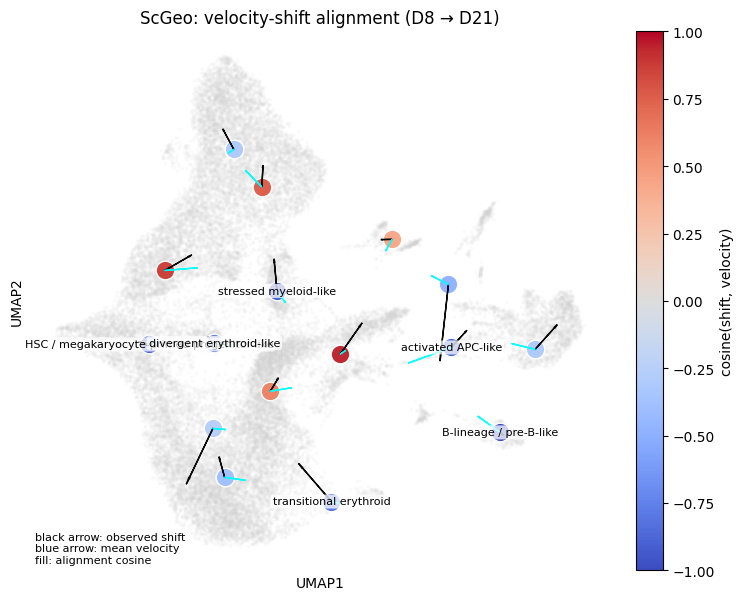

In [15]:
fig, ax, align_df = sg.pl.velocity_shift_alignment(
    adata,
    node_key="cluster_label_manual",
    condition_key="timepoint",
    group0="D8",
    group1="D21",
    basis="umap",
    velocity_basis="umap",
    min_cells=20,
    label_top_n=6,
    label_mode="discordant",
    return_data=True,
)